# Using Pre-trained Hugging Face Models

**Companion lab for MIT 15.773 Hands-On Deep Learning (Spring 2024).**

This notebook is adapted from `08_huggingface_pretrained.ipynb` for study and reproducibility. The instructional cells and code are preserved, while stored outputs are removed to keep the book portable. Run cells in order and inspect shapes, metrics, and failure cases rather than treating successful execution as the only goal.

> Some labs require a GPU, external datasets, model downloads, or API credentials. Use a hosted runtime where the notebook indicates one; never commit credentials.



# Using pre-trained models to solve "standard" NLP problems **without** fine-tuning

Adapted from https://github.com/nlp-with-transformers/notebooks/blob/main/01_introduction.ipynb

We will use the `transformers` library from HuggingFace (in particular, the `pipeline` function) to demonstrate ready-to-use pretrained models for a variety of standard NLP tasks.

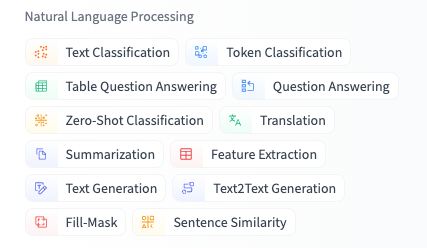

Fortunately, the library is preinstalled in Colab so we can just import it and start using it right away.

We will start with a Text Classification example.

### Text Classification

In [ ]:
text = """Dear Amazon, last week I ordered an Optimus Prime action figure \
from your online store in Germany. Unfortunately, when I opened the package, \
I discovered to my horror that I had been sent an action figure of Megatron \
instead! As a lifelong enemy of the Decepticons, I hope you can understand my \
dilemma. To resolve the issue, I demand an exchange of Megatron for the \
Optimus Prime figure I ordered. Enclosed are copies of my records concerning \
this purchase. I expect to hear from you soon. Sincerely, Bumblebee."""

In [ ]:
from transformers import pipeline

In [ ]:
classifier = pipeline("text-classification")

In [ ]:
outputs = classifier(text)

In [ ]:
outputs

In [ ]:
import pandas as pd
pd.DataFrame(outputs)

Let's try another example.


In [ ]:
inputs = ['i hated the movie',
          'if i said i loved the movie, i would be lying',
          'the movie left me speechless',
          ' incredible!',
          'almost but not quite entirely unlike anything good i have ever seen'
          ]

In [ ]:
outputs = classifier(inputs)
pd.DataFrame(outputs)

### Named Entity Recognition

In [ ]:
ner_tagger = pipeline("ner", aggregation_strategy="simple")

In [ ]:
outputs = ner_tagger(text)
pd.DataFrame(outputs)

### Question Answering

In [ ]:
reader = pipeline("question-answering")

In [ ]:
question = "What does the customer want?"
outputs = reader(question=question, context=text)
pd.DataFrame([outputs])

### Summarization

In [ ]:
summarizer = pipeline("summarization")

In [ ]:
outputs = summarizer(text, max_length=56, clean_up_tokenization_spaces=True)
print(outputs[0]['summary_text'])

Hmm, that's not great. Let's try another model.

In [ ]:
summarizer = pipeline("summarization", model="philschmid/bart-large-cnn-samsum")

In [ ]:
outputs = summarizer(text, max_length=56, clean_up_tokenization_spaces=True)
print(outputs[0]['summary_text'])

Much better!

### Text Generation

In [ ]:
from transformers import set_seed
set_seed(42) # Set the seed to get reproducible results

In [ ]:
generator = pipeline("text-generation")

In [ ]:
response = "Dear Bumblebee, I am sorry to hear that your order was mixed up."
prompt = text + "\n\nCustomer service response:\n" + response

In [ ]:
prompt

In [ ]:
outputs = generator(prompt, max_length=200)
print(outputs[0]['generated_text'])

Yikes!! A bigger model will give us a better response.

You can try the model below later. We will skip it now since it will take a while to download.

In [ ]:
generator = pipeline("text-generation", model='bigscience/bloom')

In [ ]:
outputs = generator(prompt, max_length=200)
print(outputs[0]['generated_text'])